# 小牙片分析调用样例

In [83]:
# 加载所需要的包
import os
import cv2
import glob
import base64
import time
import requests
import json
import urllib
import numpy as np
import matplotlib.pyplot as plt

<h2>定义调用规则</h2>
请根据您从我方获取的信息修改以下代码块

In [84]:
# 朝厚服务请求地址，随api文档发送
base_url = "<服务请求地址>"

# 朝厚文件服务地址，随api文档发送
file_server_url = "<服务文件服务器地址>"

# 必须传入鉴权 Header。请保护好TOKEN!!! 如果泄露请立即联系我们重置，所有使用该TOKEN的任务都会向您的账户计费
zh_token = "<贵司服务Token, 随合同发送>" # 调用所有的API都必须传入token用作鉴权

user_group = "APIClient" # 用户组，一般为 APIClient

# 贵司user_id, 随api文档发送
user_id = "<贵司user_id>"

# 如果您收到了creds.json, 下面将直接读取
if os.path.exists('../../creds.json'):
    creds = json.load(open('../../creds.json', 'r'))
    base_url = creds['base_url']
    file_server_url = creds['file_server_url']
    zh_token = creds['zh_token']
    user_id = creds['user_id']
    print("loaded creds from creds.json")

loaded creds from creds.json


In [85]:
json_call = {
    "spec_version": "1.0-snapshot",
    "spec_name": "periapical-analysis",
    "spec_group": "periapical",
    "user_group": user_group,
    "user_id": user_id
}        

### 定义回调地址

回调会在工作流运行结束后向指定地址发送一个POST请求，请求内容为一个JSON，内含4个字段

1. workflow_id (str): 对应的workflow_id
2. metadata (dict): 您启动工作流时传入的metadata
3. success (bool): 工作流是否成功（true为成功）
4. reason (str or null): 如果success为true, 该项为null. 否则为失败原因的字符串表示

如果需要回调，请uncomment以下代码块

In [ ]:
# json_call['metadata'] = { #（可选）这里可以加入metadata, 回调时会附带该信息，字典每项限制128个字符
#     "case_id": "CH-123",
#     "case_name": "ABCDE"
# }
# json_call['notification'] =[ #（可选）这里可以加入回调地址
#     {"url": "https://www.baidu.com"} # 这里可以加入多个回调地址，每个都是{"url": "xxx"}格式
# ]

## 定义输入/输出块

输入块由JSON文件中的`input_data`定义。对于二维图片，我们支持以下**输入**文件格式

```
"jpg"
"jpeg"
"png"
```

对于二维图片，输入可以采用两种形式传入：

1. 先将文件传入我们的文件服务系统，再将文件指针写入JSON调用串并调用API
2. 直接在API的JSON调用串中传入base64编码后的二进制数据

我们**强烈推荐**使用第一种方式，理由如下：

1. base64编码将增大数据流大小，提高网络延迟
2. 为保障接口性能，朝厚将拒绝过大的API请求。因此对于大文件，第二种方式会调用失败（HTTP CODE 413)

In [86]:
def upload_file(file_name):
    ext = file_name.split('.')[-1]
    data = open('../../data/' + file_name, 'rb').read()
    resp = requests.get(file_server_url + f"/scratch/{user_group}/{user_id}/upload_url?" +
                        f"postfix={ext}", # 必须指定 postfix, 即文件后缀名
                        headers={"X-ZH-TOKEN": zh_token}) # 获取带签名的上传地址
    resp.raise_for_status()

    upload_url = resp.text[1:-1] # 返回为一个单字符串JSON "string", 这里也可以用json.loads(resp.text)

    resp = requests.put(upload_url, data) # 上传至云储存服务不需要带鉴权头

    resp.raise_for_status()
    path = "/".join(urllib.parse.urlparse(upload_url).path.lstrip("/").split("/")[3:])
    urn = f"urn:zhfile:o:s:{user_group}:{user_id}:{path}"
    return urn

json_call["input_data"] = {
    "image": upload_file('face_periapical.jpg')
}

# 提交请求

使用 `/run` POST方法提交请求

In [87]:
headers = {
  "Content-Type": "application/json",
  "X-ZH-TOKEN": zh_token
}

url = base_url + '/run'

response = requests.request("POST", url, headers=headers, data=json.dumps(json_call))
response.raise_for_status()
create_result = response.json()
run_id = create_result['run_id']

# 打印任务号
print(run_id)

sa_service_1765967358-73861d79-4c0e-4b5b-8bdd-96d1ed1f418f


# 等待请求完成

使用轮询API等待请求完成，API地址为 `/run/{run_id}`

**强烈推荐使用回调方法**, 参考[定义回调地址](#定义回调地址)，回调方法无论工作流成功与否，在结束时均会向给定地址发送回调信息，您无需轮询结果

In [88]:
# 第二步： 轮询状态
url = base_url + f"/run/{run_id}"

start_time = time.time()
while time.time()-start_time < 180: # 最多等3分钟
    time.sleep(0.3) # 轮询间隔
    response = requests.request("GET", url, headers=headers)
    result = response.json()
    if result['completed'] or result['failed']:
        break
    
if not result['completed']:
    if result['failed']:
        raise ValueError("API运行错误，原因： " + str(result['reason_public']))
    raise TimeoutError("API超时")

print("API运行时间： {}s".format(time.time()-start_time))

API运行时间： 3.5446550846099854s


# 获取请求结果

使用 `/data/{run_id}` 获得该工作流所有输出数据，使用 `/data/{run_id}/{key}` 获取某一项数据

In [89]:
url = base_url + f"/data/{run_id}"
response = requests.request("GET", url, headers=headers)
result = response.json()

# 样例API输出结果展示

以下为该小牙片分析API的输出结果展示。该部分之上代码对所有以二维图片作为输入的API通用，以下部分仅针对小牙片分析输出处理及展示,

小牙片接口具体输出规则及字段见: https://www.chohotech.com/docs/cloud-zh/#/module/periapical-1

In [ ]:
def vis_periapical_result(img, result):
    """
    小牙片分析 API 输出结果展示（新版）
    - img: 原始小牙片图像 (BGR)
    - result: API 返回的 result 字段
    """
    vis = img.copy()

    # ========= 1. 绘制每颗牙齿轮廓 =========
    teeth = result.get("teeth", {})
    for tooth_id, tooth_info in teeth.items():
        points = tooth_info.get("points", [])
        # 绘制轮廓
        for i in range(len(points)):
            x1, y1 = map(int, points[i])
            cv2.circle(vis, (x1, y1), 2, (255, 0, 0), -1)  # 蓝色点
            if i > 0:
                x0, y0 = map(int, points[i - 1])
                cv2.line(vis, (x0, y0), (x1, y1), (255, 0, 0), 1)
                
        # ========= 2. 绘制牙齿结构 =========
        struct = tooth_info.get("struct", {})
        struct_colors = {"enamel": (255, 255, 0), "dentin": (0, 255, 255), "pulp": (0, 0, 255)}
        for struct_name, struct_points_list in struct.items():
            color = struct_colors.get(struct_name, (0, 255, 0))
            for contour in struct_points_list:
                for i in range(len(contour)):
                    x1, y1 = map(int, contour[i])
                    cv2.circle(vis, (x1, y1), 2, color, -1)
                    if i > 0:
                        x0, y0 = map(int, contour[i - 1])
                        cv2.line(vis, (x0, y0), (x1, y1), color, 1)
                        
        # ========= 3. 绘制牙齿关键点 =========
        landmark = tooth_info.get("landmark", {})
        for name, kp in landmark.items():
            x, y = int(kp[0]), int(kp[1])
            cv2.circle(vis, (x, y), 3, (255, 255, 255), -1)  # 白色点

    # ========= 4. 绘制疾病点 =========
    disease = result.get("disease", {})
    disease_colors = {90204: (0, 0, 255), 90206: (0, 255, 255)}  # 龋齿:red, 根尖周炎:cyan，可自定义
    for disease_id, dis_info in disease.items():
        points = dis_info.get("points", [])
        label = dis_info.get("label")
        color = disease_colors.get(label, (0, 255, 0))
        for pt in points:
            x, y = map(int, pt)
            cv2.circle(vis, (x, y), 3, color, -1)

    return vis

In [92]:

img = cv2.imread('../../data/face_periapical.jpg')

In [93]:
vis = vis_periapical_result(img, result['result'])

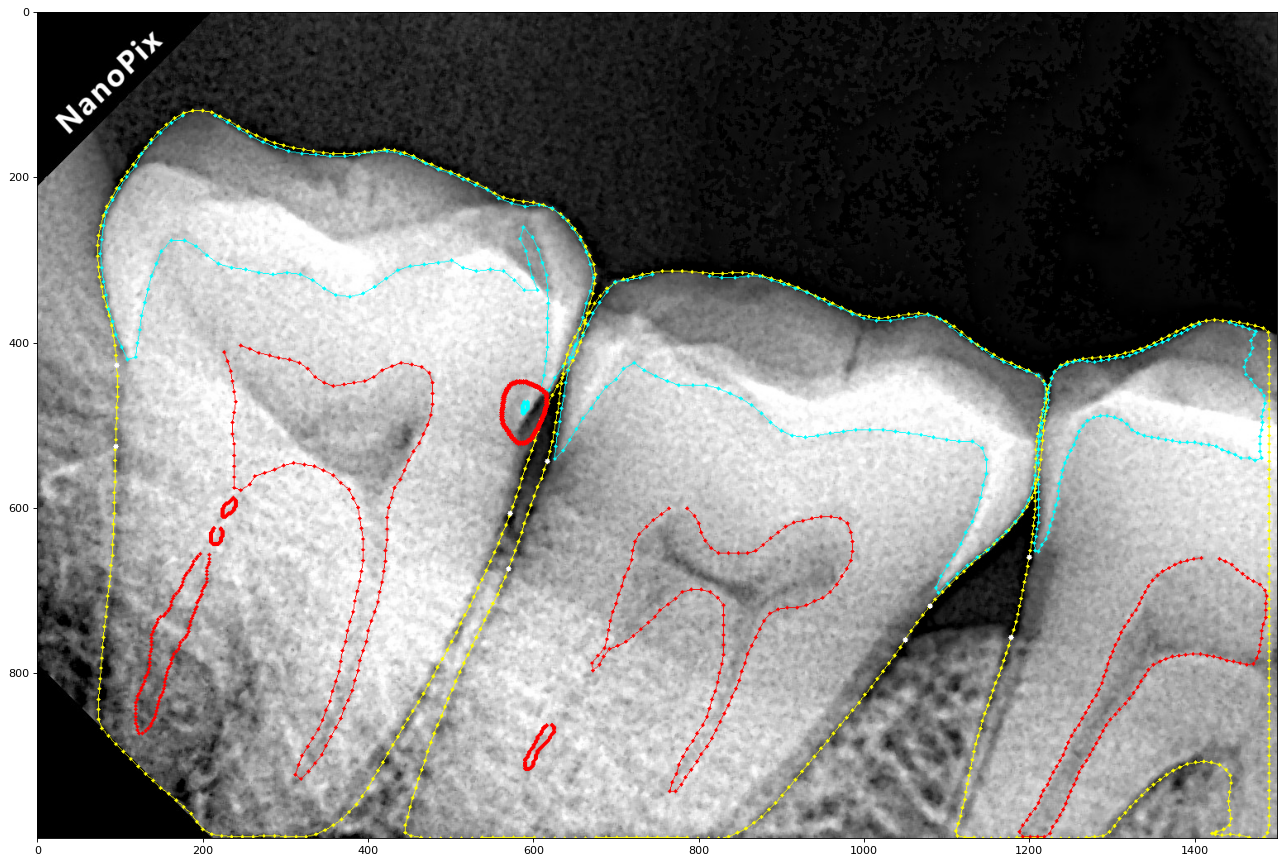

In [94]:
plt.figure(figsize=(20, 14), dpi=80)
plt.imshow(vis[:,:,::-1])
plt.show()